# How to compute a particle decay

*For a student who has met Feynman rules and Dirac spinors, but has never carried a
decay calculation all the way to a number.*

A particle decays. What we measure is **how fast**: a lifetime, or equivalently a
**width** $\Gamma$, and the **fractions** that go into each final state. What theory
provides is a Lagrangian. This notebook is the bridge between the two.

We will do the calculation the way you would on paper — spin sums, Dirac traces,
phase space — using `feynlag` to carry the algebra rather than to hide it. Only once
we have built a width from scratch will we reach for the machine that does it in one
line.

**Roadmap**

1. Widths, lifetimes and branching ratios
2. The master formula
3. Two-body phase space
4. From a Feynman rule to an amplitude
5. Squaring: why spin sums become traces
6. Trace theorems, hands-on
7. $h \to \tau\tau$ and the $\beta^3$ threshold
8. Polarisation sums: $Z \to \ell\ell$ and $W \to \ell\nu$
9. Chirality: why V−A gives exactly half
10. The whole Standard Model at once
11. Off-shell decays: reopening the closed channel
12. Two ways to get it silently wrong
13. Your own model: a $Z'$
14. Recap

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from feynlag import *
from feynlag.pheno import (
    DecayCalculator, DiracParticle, TwoBodyKinematics, collect_decay_vertices,
    ffs_squared, ffv_squared, kallen, scalar_offshell_vv_width,
    scalar_vv_s12_integral, two_body_momentum, two_body_phase_space,
    vvs_squared,
)
from feynlag.pheno.lorentz import contract_to_dots, dirac_trace, index, slashed

sp.init_printing()

Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 28 ("    '003DA5',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 29 ("    'C0392B',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 30 ("    '1A6B3A',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 31 ("    'FFBE00',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 32 ("    '3F6FD1',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 33 ("    '8E44AD',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 34 ("    'E67E22',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 35 ("    '17A589',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 36 ("    '2C3E50',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 37 ("    'CB4335'])")


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 21 ('axes.edgecolor    : #4A4A6A'): Key axes.edgecolor: '' does not look like a color arg


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 27 ("axes.prop_cycle : cycler('color', ["): Key axes.prop_cycle: "cycler('color', [" is not a valid cycler construction: Could not parse "cycler('color', [": '[' was never closed (<unknown>, line 1)


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 95 ('patch.edgecolor       : face'): Key patch.edgecolor: 'face' does not look like a color arg


## 1. Widths, lifetimes and branching ratios

An unstable particle has a survival probability that falls exponentially,
$P(t) = e^{-\Gamma t}$. The constant $\Gamma$ is the **decay width**, and it is just an
inverse lifetime,

$$\tau = \frac{\hbar}{\Gamma}.$$

Because we work in natural units, $\Gamma$ carries units of **energy** — quoted in GeV,
even though it describes a time.

If several final states are available, each has its own **partial width** $\Gamma_i$.
They simply add, and the fraction going into channel $i$ is the **branching ratio**

$$\mathrm{BR}_i = \frac{\Gamma_i}{\Gamma_\text{tot}},
\qquad \Gamma_\text{tot} = \sum_i \Gamma_i, \qquad \sum_i \mathrm{BR}_i = 1.$$

The $Z$ boson makes this concrete.

In [ ]:
hbar = 6.582119569e-25          # GeV*s
Gamma_Z = 2.4952                # GeV, PDG total width

print(f"Gamma(Z) = {Gamma_Z} GeV")
print(f"tau(Z)   = {hbar / Gamma_Z:.3e} s")

Gamma(Z) = 2.4952 GeV
tau(Z)   = 2.638e-25 s


Around $2.6\times10^{-25}$ s. That is the number we are going to compute — starting from
nothing but a Lagrangian.

## 2. The master formula

Fermi's golden rule says a transition rate is *(matrix element)² × (density of final
states)*. Made relativistic and specialised to one particle of mass $M$ decaying at
rest, it reads

$$\boxed{\;\Gamma = \frac{1}{2M}\int \overline{|\mathcal{M}|^2}\;\mathrm{d}\Phi_n\;}$$

Three pieces, and we will take them one at a time:

- $1/2M$ — relativistic normalisation of the decaying state.
- $\mathrm{d}\Phi_n$ — **phase space**: how much room the final state has. Pure
  kinematics; no dynamics at all (§3).
- $\overline{|\mathcal{M}|^2}$ — the **squared amplitude**, where all the physics lives
  (§4–§9).

The bar is not decoration. Real experiments do not prepare or measure spin here, so we

- **sum** over final-state spins and polarisations (we do not care which one we got),
- **average** over the decaying particle's, dividing by its $2s+1$ states — $1$ for a
  scalar, $3$ for a massive vector.

Getting that factor of 3 wrong for a vector is one of the most common slips.

## 3. Two-body phase space

For a two-body final state the integral collapses to something you can write down. In
the rest frame the two daughters come out back to back with equal and opposite momenta,
so once you fix their common magnitude $|k|$ there is nothing left to integrate but an
overall solid angle.

Energy conservation fixes $|k|$ through the **Källén triangle function**

$$\lambda(x,y,z) = x^2+y^2+z^2-2xy-2yz-2zx,
\qquad |k| = \frac{\sqrt{\lambda(M^2,m_1^2,m_2^2)}}{2M},$$

and the whole phase-space factor becomes

$$\int\mathrm{d}\Phi_2 \;\longrightarrow\; \frac{\sqrt{\lambda(M^2,m_1^2,m_2^2)}}{16\pi M^3}\,
\quad\text{(after the }1/2M\text{)}.$$

Kallen lambda(M^2, m1^2, m2^2):



daughter momentum |k|:


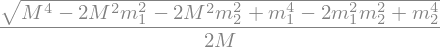


the full phase-space factor sqrt(lambda)/(16 pi M^3):


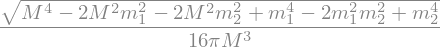

In [ ]:
M, m1, m2 = sp.symbols('M m_1 m_2', positive=True)

kin = TwoBodyKinematics(M, m1, m2)

print("Kallen lambda(M^2, m1^2, m2^2):")
display(sp.factor(kallen(M**2, m1**2, m2**2)))

print("\ndaughter momentum |k|:")
display(two_body_momentum(M, m1, m2))

print("\nthe full phase-space factor sqrt(lambda)/(16 pi M^3):")
display(kin.phase_space())

Note the factorised form of $\lambda$: it contains $\big(M-(m_1+m_2)\big)$. The moment
$M$ drops below $m_1+m_2$ that factor changes sign, $\sqrt\lambda$ becomes imaginary and
the decay is **closed**. Watch this happen.

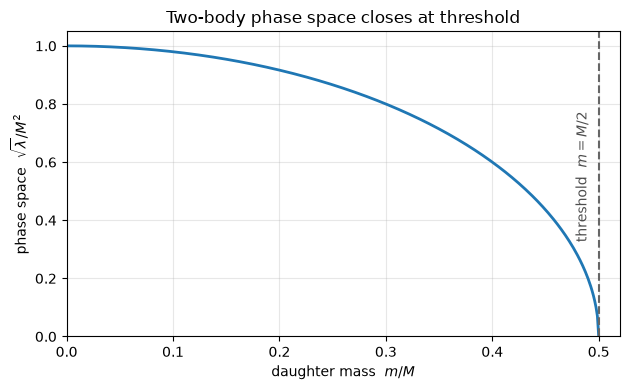

In [ ]:
# equal-mass daughters: how much room is left as they get heavier?
x = np.linspace(0.0, 0.5, 400)                  # x = m/M
ps = np.sqrt(np.clip(1 - 4*x**2, 0, None))      # sqrt(lambda)/M^2 for m1 = m2 = m

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(x, ps, lw=2, color='#1f77b4')
ax.axvline(0.5, ls='--', color='0.4')
ax.text(0.492, 0.55, 'threshold  $m = M/2$', rotation=90,
        ha='right', va='center', color='0.3')
ax.set_xlabel(r'daughter mass  $m/M$')
ax.set_ylabel(r'phase space  $\sqrt{\lambda}/M^2$')
ax.set_title('Two-body phase space closes at threshold')
ax.set_xlim(0, 0.52); ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The curve reaches zero at $m = M/2$ with a **vertical tangent** — the square root. This
is pure kinematics: we have not said one word about the interaction. Any decay, of any
particle, through any force, is switched off by this factor as the daughters get heavy
enough. Dynamics can only change *how fast* the curve falls, never *that* it falls.

## 4. From a Feynman rule to an amplitude

Now the dynamics. `feynlag` reads vertices straight off a Lagrangian — that is what the
other tutorials in this series do. Let us build the electroweak Standard Model with one
lepton generation and simply ask it for its vertices.

(The build is condensed here; `SM_Feynman_Rules_Tutorial.ipynb` walks it stage by stage.)

In [ ]:
GW, G1, VEV, MH = 0.6535, 0.3580, 246.0, 125.25
MZ, MW, MTAU = 91.1876, 80.377, 1.77686

# The electroweak scaffold — gauge groups, Higgs, potential and the
# physical-basis rotations — comes ready-made from feynlag.models. (The
# SM_Feynman_Rules_Tutorial builds all of this by hand, stage by stage.)
ew = electroweak_scaffold(gw=GW, g1=G1, v=VEV, mh=MH)
SU2L, U1Y, H = ew.SU2L, ew.U1Y, ew.H
gw, g1, v = ew.gw, ew.g1, ew.v          # convenience aliases for later cells
ytau = ExternalParameter("ytau", sp.sqrt(2) * MTAU / VEV, positive=True)

# the one piece of physics that IS the point here: a tau lepton + its Yukawa
Ll = WeylFermion("Ll", reps={SU2L: 2, U1Y: -sp.Rational(1, 2)}, chirality="L",
                 nflavors=1, component_names=["nuL", "tauL"])
tauR = WeylFermion("tauR", reps={U1Y: -1}, chirality="R", nflavors=1,
                   component_names=["tauR"])

i = sp.Symbol("i", integer=True)
L = Lagrangian()
ew.add_higgs(L)                                    # kinetic + potential
L.add(fermion_gauge_current(Ll, i) + fermion_gauge_current(tauR, i), sector="gauge")

nuLb, tauLb = Ll.bar_components
nuL, tauL = Ll.components
tauRb, tauRc = tauR.bar_components[0], tauR.components[0]
yuk = -ytau.s * (Bilinear(nuLb[i], diracPR, tauRc[i]) * H.components[0]
                 + Bilinear(tauLb[i], diracPR, tauRc[i]) * H.components[1])
L.add(yuk + sp.conjugate(yuk), sector="yukawa")

model = Model("SM_lepton", gauge_groups=ew.gauge_groups,
              fields=ew.fields + [Ll, tauR],
              parameters=ew.parameters + [ytau], lagrangian=L)
model.solve_tadpoles([ew.mu2])

# physical basis: the standard Weinberg + W± rotations, in one call
phys = to_physical_basis(model, ew)
Z, A, Wp, Wm, h, G0, Gp, Gm = (phys.Z, phys.A, phys.Wp, phys.Wm,
                               phys.h, phys.G0, phys.Gp, phys.Gm)
cmap, bosons = phys.cmap, phys.bosons

# a Dirac fermion is two Weyl fields in feynlag: say which legs are one particle
tau, taubar, nutau, nutaubar = sp.symbols("tau taubar nu_tau nu_taubar")
particle_map = {tauL[i]: tau, tauRc[i]: tau, tauLb[i]: taubar, tauRb[i]: taubar,
                nuL[i]: nutau, nuLb[i]: nutaubar}
print("model built")

model built


Every fermion vertex feynlag produces has the same shape,

$$\Gamma \;=\; g_L P_L + g_R P_R \qquad\text{or}\qquad
\Gamma^\mu \;=\; \gamma^\mu\,(g_L P_L + g_R P_R),$$

a **scalar** sandwich or a **vector** current, each with a left- and a right-handed
coupling. So a vertex is fully specified by the pair $(g_L, g_R)$. Here they are for
the $Z$ and the Higgs:

In [ ]:
vertices = collect_decay_vertices(model, bosons, fermion_sectors=("gauge", "yukawa"),
                                  conjugate_map=cmap, particle_map=particle_map)

for vtx in vertices:
    if vtx.vertex_type in ("FFV", "FFS") and (Z in vtx.particles or h in vtx.particles):
        legs = " ".join(str(p) for p in vtx.particles)
        print(f"{vtx.vertex_type}  {legs}")
        print(f"      g_L = {sp.factor(sp.expand(vtx.g_left))}")
        print(f"      g_R = {sp.factor(sp.expand(vtx.g_right))}")

FFV  taubar tau Z
      g_L = I*(g1 - gw)*(g1 + gw)/(2*sqrt(g1**2 + gw**2))
      g_R = I*g1**2/sqrt(g1**2 + gw**2)
FFV  nu_taubar nu_tau Z
      g_L = I*sqrt(g1**2 + gw**2)/2
      g_R = 0
FFS  taubar tau H0_r
      g_L = -sqrt(2)*I*ytau/2
      g_R = -sqrt(2)*I*ytau/2


Read these off against what you know:

- $Z\tau\tau$ has $g_L \ne g_R$ — the weak interaction is **chiral**.
- $Z\nu\nu$ has $g_R = 0$ exactly. There is no right-handed neutrino to couple to.
- $h\tau\tau$ has $g_L = g_R = -i\,y_\tau/\sqrt2 = -i\,m_\tau/v$ — the Higgs is
  **not** chiral, and it couples in proportion to mass.

(The factors of $i$ are the Feynman-rule $i$; they cancel when we square.)

## 5. Squaring: why spin sums become traces

The amplitude for a scalar decaying to a fermion pair is

$$\mathcal{M} = \bar u(p_1)\,\Gamma\, v(p_2),$$

a single complex number once the spinors are fixed. We need $|\mathcal{M}|^2$ summed
over the final spins. Using $\mathcal{M}^* = \bar v(p_2)\,\bar\Gamma\, u(p_1)$ with
$\bar\Gamma = \gamma^0\Gamma^\dagger\gamma^0$,

$$\sum_\text{spins}|\mathcal{M}|^2
= \sum_{s_1,s_2}\bar u(p_1)\Gamma v(p_2)\,\bar v(p_2)\bar\Gamma u(p_1).$$

Now the key step. The **completeness relations**

$$\sum_s u(p)\bar u(p) = \not p + m, \qquad \sum_s v(p)\bar v(p) = \not p - m$$

replace each spinor pair by a $4\times4$ matrix. What is left is a product of matrices
sandwiched between $\bar u \dots u$ with the *same* index summed at both ends — which is
by definition a **trace**:

$$\boxed{\;\sum_\text{spins}|\mathcal{M}|^2
= \mathrm{Tr}\big[(\not p_1 + m_1)\,\Gamma\,(\not p_2 - m_2)\,\bar\Gamma\big]\;}$$

This is why every decay calculation in the textbooks turns into trace algebra. The
spins are gone; only momenta and masses remain.

In [ ]:
mu, nu = index('mu'), index('nu')
p1, p2 = kin.p1, kin.p2

# the spin sums themselves
print("sum u ubar = p1_slash + m1 :", slashed(p1, mu) + m1)
print("sum v vbar = p2_slash - m2 :", slashed(p2, nu) - m2)

sum u ubar = p1_slash + m1 : m_1 + p1(L_0)*GammaMatrix(-L_0)
sum v vbar = p2_slash - m2 : -m_2 + p2(L_0)*GammaMatrix(-L_0)


## 6. Trace theorems, hands-on

Four facts do almost all the work:

$$\mathrm{Tr}[\text{odd number of }\gamma] = 0, \qquad
\mathrm{Tr}[\gamma^\mu\gamma^\nu] = 4g^{\mu\nu},$$

$$\mathrm{Tr}[\gamma^\mu\gamma^\nu\gamma^\rho\gamma^\sigma]
= 4\left(g^{\mu\nu}g^{\rho\sigma} - g^{\mu\rho}g^{\nu\sigma} + g^{\mu\sigma}g^{\nu\rho}\right),
\qquad \mathrm{Tr}[P_{L,R}] = 2.$$

The first one is why mass terms and momentum terms never mix: each $\not p$ brings one
$\gamma$, so a term with an odd number of them dies.

Let us evaluate the simplest non-trivial trace, $\mathrm{Tr}[\not p_1 \not p_2]$, in the
two steps you would do by hand.

In [ ]:
chain = slashed(p1, mu) * slashed(p2, nu)

step1 = dirac_trace(chain)
print("step 1 -- apply Tr[gamma^mu gamma^nu] = 4 g^{mu nu}:")
print("   ", step1, "     i.e.  4 p1.p2")

step 1 -- apply Tr[gamma^mu gamma^nu] = 4 g^{mu nu}:
    4*p1(L_0)*p2(-L_0)      i.e.  4 p1.p2


The result is still written with an abstract contracted index. The second step puts the
momenta **on shell** — a two-body final state has only three independent invariants, and
all of them are fixed by the masses:

$$p_1^2 = m_1^2, \qquad p_2^2 = m_2^2, \qquad
p_1\!\cdot\! p_2 = \frac{M^2 - m_1^2 - m_2^2}{2},$$

the last from squaring $M^2 = (p_1+p_2)^2$.

In [ ]:
print("on-shell dot products:")
print("   p1.p1 =", kin.dot(p1, p1))
print("   p2.p2 =", kin.dot(p2, p2))
print("   p1.p2 =", kin.dot(p1, p2))

step2 = contract_to_dots(step1, kin.dot)
print("\nstep 2 -- substitute them:")
print("   Tr[p1_slash p2_slash] =", sp.expand(step2))

on-shell dot products:
   p1.p1 = m_1**2
   p2.p2 = m_2**2
   p1.p2 = M**2/2 - m_1**2/2 - m_2**2/2

step 2 -- substitute them:
   Tr[p1_slash p2_slash] = 2*M**2 - 2*m_1**2 - 2*m_2**2


So $\mathrm{Tr}[\not p_1\not p_2] = 4\,p_1\!\cdot\!p_2 = 2M^2 - 2m_1^2 - 2m_2^2$: a
plain function of the masses. Every squared amplitude below is built from exactly these
two steps.

## 7. $h \to \tau\tau$ and the $\beta^3$ threshold

Assemble the scalar case. With $\Gamma = g_LP_L + g_RP_R$ the conjugate is
$\bar\Gamma = \bar g_L P_R + \bar g_R P_L$ (bare projectors swap under
$\gamma^0(\cdot)^\dagger\gamma^0$), and pushing projectors through with
$P_{L,R}\not p = \not p P_{R,L}$, $P_LP_R = 0$ splits the trace cleanly in two:

- the **chirality-diagonal** terms keep the momenta and lose the masses,
- the **chirality-mixing** terms keep $m_1m_2$ and lose the momenta.

$$\sum|\mathcal{M}|^2 = 2(|g_L|^2+|g_R|^2)\,(p_1\!\cdot\!p_2)
- 4\,m_1m_2\,\mathrm{Re}(g_L\bar g_R).$$

In [ ]:
gL, gR = sp.symbols('g_L g_R', real=True)
mh, mf = sp.symbols('m_h m_f', positive=True)

kin_h = TwoBodyKinematics(mh, mf, mf)
amp2 = ffs_squared(gL, gR, kin_h)
print("summed |M|^2 for S -> f fbar:")
display(sp.factor(sp.expand(amp2)))

summed |M|^2 for S -> f fbar:


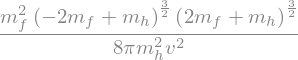

matches  m_h m_f^2 beta^3 / (8 pi v^2)? True


In [ ]:
# the Higgs is not chiral: g_L = g_R = m_f/v
vv = sp.Symbol('v', positive=True)
width_h = sp.simplify(ffs_squared(mf/vv, mf/vv, kin_h) * kin_h.phase_space())
display(sp.factor(width_h))

beta = sp.sqrt(1 - 4*mf**2/mh**2)
expected = mh * mf**2 * beta**3 / (8*sp.pi*vv**2)
print("matches  m_h m_f^2 beta^3 / (8 pi v^2)?",
      sp.simplify(sp.expand(width_h - expected)) == 0)

$$\Gamma(h\to f\bar f) = \frac{N_c\, m_h\, m_f^2\,\beta^3}{8\pi v^2},
\qquad \beta = \sqrt{1 - 4m_f^2/m_h^2}.$$

Two things to notice.

**$\Gamma \propto m_f^2$.** The Higgs couples proportionally to mass, so it decays
preferentially to the heaviest thing it can reach. That single fact drives the entire
Higgs search programme.

**$\beta^3$, not $\beta$.** One power of $\beta$ is the phase space from §3. The other
two come from the *dynamics*: a CP-even scalar decaying to a fermion pair produces them
in a **P-wave** ($\ell=1$), and an $\ell$-wave amplitude is suppressed by
$\beta^{\ell}$ near threshold — $\beta^{2\ell}$ in the rate. A CP-**odd** scalar decays
S-wave and would give plain $\beta$.

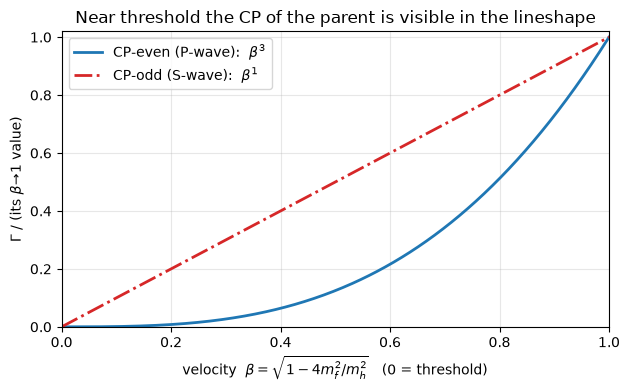

In [ ]:
b = np.linspace(0, 1, 400)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(b, b**3, lw=2, color='#1f77b4', label=r'CP-even (P-wave):  $\beta^3$')
ax.plot(b, b, lw=2, color='#d62728', ls='-.', label=r'CP-odd (S-wave):  $\beta^1$')
ax.set_xlabel(r'velocity  $\beta=\sqrt{1-4m_f^2/m_h^2}$   (0 = threshold)')
ax.set_ylabel(r'$\Gamma$ / (its $\beta\!\to\!1$ value)')
ax.set_title('Near threshold the CP of the parent is visible in the lineshape')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

Right at threshold ($\beta\to0$) the CP-even curve leaves the axis much more slowly. This
is not an academic distinction: the shape of a threshold turn-on is one of the ways the
spin and CP of a new particle get pinned down experimentally.

## 8. Polarisation sums: $Z\to\ell\ell$ and $W\to\ell\nu$

A decaying **vector** brings two changes. Its amplitude carries a polarisation vector,
$\mathcal{M} = \epsilon_\mu \bar u\,\Gamma^\mu v$, so squaring needs the polarisation sum

$$\sum_\text{pol}\epsilon_a\epsilon^*_b = -g_{ab} + \frac{P_aP_b}{M^2},$$

and because a massive vector has three states we must **average**, dividing by 3.
Everything else is the same trace algebra.

matches the closed form? True


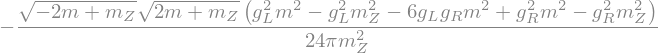

In [ ]:
mZ = sp.Symbol('m_Z', positive=True)
m = sp.Symbol('m', positive=True)

kin_Z = TwoBodyKinematics(mZ, m, m)
width_V = sp.simplify(ffv_squared(gL, gR, kin_Z) * kin_Z.phase_space())

betaZ = sp.sqrt(1 - 4*m**2/mZ**2)
closed = (mZ*betaZ/(24*sp.pi)) * ((gL**2 + gR**2)*(1 - m**2/mZ**2)
                                  + 6*gL*gR*m**2/mZ**2)
print("matches the closed form?", sp.simplify(sp.expand(width_V - closed)) == 0)
display(sp.factor(width_V))

$$\Gamma(V\to f\bar f) = \frac{M\beta}{24\pi}
\left[(g_L^2+g_R^2)\Big(1-\frac{m^2}{M^2}\Big) + 6\,g_Lg_R\frac{m^2}{M^2}\right].$$

Note the $g_Lg_R$ term: it needs **both** chiralities *and* a mass. It is the piece that
will bite us in §12.

Now put in the Standard Model's own couplings and compare with the PDG.

In [ ]:
g, gp = gw.s, g1.s
gZ = sp.sqrt(g**2 + gp**2)

# SM neutral-current couplings (massless limit for the leptons)
couplings = {
    r'$Z \to \nu\bar\nu$':      (gZ/2, 0),                       # purely left-handed
    r'$Z \to \tau^+\tau^-$':    ((gp**2 - g**2)/(2*gZ), gp**2/gZ),
}
vals = {g: GW, gp: G1}

rows = []
for label, (cl, cr) in couplings.items():
    w = ffv_squared(cl, cr, TwoBodyKinematics(mZ, 0, 0)) * TwoBodyKinematics(mZ, 0, 0).phase_space()
    rows.append((label, float(sp.simplify(w).subs(vals).subs(mZ, MZ))))

for label, w in rows:
    print(f"{label:26s}  Gamma = {w:.4f} GeV")

$Z \to \nu\bar\nu$          Gamma = 0.1679 GeV
$Z \to \tau^+\tau^-$        Gamma = 0.0844 GeV


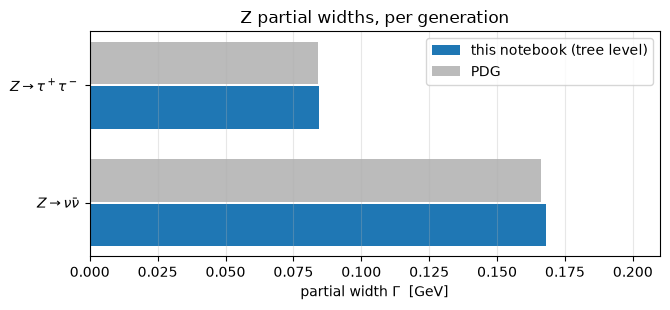

In [ ]:
pdg = {r'$Z \to \nu\bar\nu$': 0.1663, r'$Z \to \tau^+\tau^-$': 0.0841}

labels = [r[0] for r in rows]
ours = [r[1] for r in rows]
theirs = [pdg[l] for l in labels]
y = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.barh(y - 0.19, ours,   height=0.36, color='#1f77b4', label='this notebook (tree level)')
ax.barh(y + 0.19, theirs, height=0.36, color='#bbbbbb', label='PDG')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel(r'partial width $\Gamma$  [GeV]')
ax.set_title('Z partial widths, per generation')
ax.set_xlim(0, 0.21)
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Two tree-level numbers landing within about 1% of experiment — the residual is genuine
higher-order physics we have not included.

And note *why* the invisible channel is the bigger one. The neutrino is purely
left-handed, so it gets the full $g_L^2$ with nothing subtracted; the charged lepton's
left- and right-handed couplings are individually smaller. Chirality is directly visible
in the bar chart.

## 9. Chirality: why V−A gives exactly half

The weak charged current is pure $V-A$: only $P_L$. What does that do to a width?

Since $P_L = \tfrac12(1-\gamma_5)$ and the projector is idempotent, a chiral current
keeps exactly half of the vector-current trace. So a $g_R = 0$ coupling should give
precisely half the width of a $g_L = g_R = g$ one.

In [ ]:
gsym, Msym = sp.symbols('g M', positive=True)
kin_m0 = TwoBodyKinematics(Msym, 0, 0)

vector = sp.simplify(ffv_squared(gsym, gsym, kin_m0) * kin_m0.phase_space())
chiral = sp.simplify(ffv_squared(gsym, 0, kin_m0) * kin_m0.phase_space())

print("vector current  g(gamma^mu)        :", vector, "   = g^2 M / 12 pi")
print("chiral current  g(gamma^mu P_L)    :", chiral, "   = g^2 M / 24 pi")
print("exactly half?", sp.simplify(vector - 2*chiral) == 0)

# the W: coupling is g/sqrt(2), purely left-handed
mW = sp.Symbol('m_W', positive=True)
kin_W = TwoBodyKinematics(mW, 0, 0)
width_W = sp.simplify(ffv_squared(gsym/sp.sqrt(2), 0, kin_W) * kin_W.phase_space())
print("\nGamma(W -> l nu) =", width_W, "  = g^2 m_W / 48 pi")
print("numerically      =", float(width_W.subs({gsym: GW, mW: MW})), "GeV   (PDG 0.2264)")

vector current  g(gamma^mu)        : M*g**2/(12*pi)    = g^2 M / 12 pi
chiral current  g(gamma^mu P_L)    : M*g**2/(24*pi)    = g^2 M / 24 pi
exactly half? True



Gamma(W -> l nu) = g**2*m_W/(48*pi)   = g^2 m_W / 48 pi
numerically      = 0.2276312410961552 GeV   (PDG 0.2264)


A word on $\gamma_5$, because it is where hand calculations go wrong. Writing
$P_L = \tfrac12(1-\gamma_5)$ leaves a term $\mathrm{Tr}[X\gamma_5]$, which produces the
totally antisymmetric $\epsilon^{\mu\nu\rho\sigma}$.

For a **two-body** decay that term is always zero, and it is worth seeing why: $\epsilon$
needs four *independent* four-vectors to be non-zero, but a 1→2 final state offers only
two independent momenta ($P = p_1+p_2$ is not a third), and any leftover free index gets
contracted with the polarisation sum, which is **symmetric**. Antisymmetric times
symmetric vanishes.

That argument fails for a three-body decay — which is exactly why `feynlag` refuses to
drop the term unless it can prove the conditions hold, rather than assuming it.

## 10. The whole Standard Model at once

Everything so far — vertices, spin sums, traces, phase space, thresholds — is what
`DecayCalculator` automates. Having done it by hand, here is the machine.

You give it the model, a mass for every leg, and the map that says which Weyl legs form
one Dirac particle. It finds every three-leg vertex containing the parent and returns a
width per channel.

Z -> taubar tau


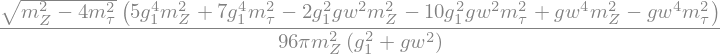

Z -> nu_taubar nu_tau


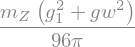

In [ ]:
mZs, mWs, mhs, mtaus = sp.symbols("m_Z m_W m_h m_tau", positive=True)
masses = {Z: mZs, Wp: mWs, Wm: mWs, A: 0, h: mhs,
          tau: mtaus, taubar: mtaus, nutau: 0, nutaubar: 0}

calc = DecayCalculator(model, masses, boson_fields=bosons,
                       fermion_sectors=("gauge", "yukawa"),
                       conjugate_map=cmap, particle_map=particle_map,
                       parameters=model.parameters)

for children, width in calc.partial_widths(Z).items():
    print("Z ->", " ".join(str(c) for c in children))
    display(sp.simplify(width))

In [ ]:
numbers = {mZs: MZ, mWs: MW, mhs: MH, mtaus: MTAU}

for parent, name in ((Z, 'Z'), (Wp, 'W+'), (h, 'h')):
    widths = calc.numeric_partial_widths(parent, extra=numbers)
    total = sum(widths.values())
    print(f"{name}:")
    for children, w in sorted(widths.items(), key=lambda kv: str(kv[0])):
        kids = " ".join(str(c) for c in children)
        tag = "" if w else "   (closed)"
        print(f"    -> {kids:<16} {w:9.5f} GeV{tag}")
    if total:
        print(f"    lifetime from these channels: {hbar/total:.3e} s")

Z:
    -> nu_taubar nu_tau   0.16787 GeV
    -> taubar tau         0.08424 GeV
    lifetime from these channels: 2.611e-24 s


W+:
    -> nu_taubar tau      0.22746 GeV
    lifetime from these channels: 2.894e-24 s


h:
    -> Wm Wp              0.00000 GeV   (closed)
    -> Z Z                0.00000 GeV   (closed)
    -> taubar tau         0.00026 GeV
    lifetime from these channels: 2.535e-21 s


Compare the $Z$ line with §1: we started from $\Gamma_\text{tot}=2.4952$ GeV and a
lifetime of $2.6\times10^{-25}$ s. Our number is longer because we built only *one*
lepton generation and no quarks — the real $Z$ has many more channels open, so it decays
faster. Add them and you converge on the measured value.

### The Higgs branching ratios

Nothing stops us from asking what the Higgs *would* do at a different mass. This
reproduces one of the most familiar plots in particle physics.

One practical point, and it is the subject of §12: we cannot call
`numeric_partial_widths` at every point of a fine grid — it re-derives the widths
symbolically each time. Instead take each symbolic width **once**, `lambdify` it, and
apply the threshold condition explicitly.

In [ ]:
higgs_widths = calc.partial_widths(h)
param_vals = model.parameters.numeric()

grid = np.linspace(20, 300, 561)
thresholds = {(Wm, Wp): 2*MW, (Z, Z): 2*MZ, (taubar, tau): 2*MTAU}
pretty = {(Wm, Wp): r'$W^+W^-$', (Z, Z): r'$ZZ$', (taubar, tau): r'$\tau^+\tau^-$'}

curves = {}
for key, expr in higgs_widths.items():
    f = sp.lambdify(mhs, expr.subs(param_vals).subs({mZs: MZ, mWs: MW, mtaus: MTAU}),
                    "numpy")
    with np.errstate(invalid='ignore'):
        y = np.where(grid > thresholds[key], f(grid), 0.0)
    curves[key] = np.nan_to_num(y)          # below threshold sqrt(lambda) is imaginary

total = sum(curves.values())
for mtest in (125.25, 170, 200, 300):
    j = int(np.argmin(abs(grid - mtest)))
    br = {pretty[k]: curves[k][j]/total[j] for k in curves}
    print(f"m_h = {mtest:6.2f} GeV   Gamma_tot = {total[j]:8.4f} GeV   " +
          "  ".join(f"BR({n}) = {x:.3f}" for n, x in br.items()))

m_h = 125.25 GeV   Gamma_tot =   0.0003 GeV   BR($W^+W^-$) = 0.000  BR($ZZ$) = 0.000  BR($\tau^+\tau^-$) = 1.000
m_h = 170.00 GeV   Gamma_tot =   0.3711 GeV   BR($W^+W^-$) = 0.999  BR($ZZ$) = 0.000  BR($\tau^+\tau^-$) = 0.001
m_h = 200.00 GeV   Gamma_tot =   1.4227 GeV   BR($W^+W^-$) = 0.734  BR($ZZ$) = 0.266  BR($\tau^+\tau^-$) = 0.000
m_h = 300.00 GeV   Gamma_tot =   8.4429 GeV   BR($W^+W^-$) = 0.688  BR($ZZ$) = 0.312  BR($\tau^+\tau^-$) = 0.000


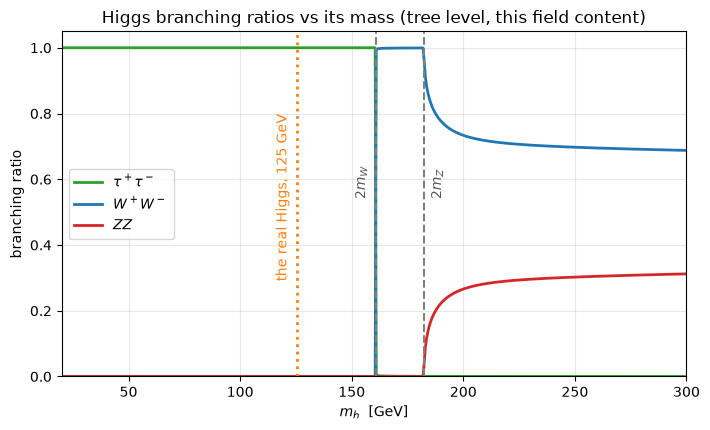

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
colors = {(Wm, Wp): '#1f77b4', (Z, Z): '#d62728', (taubar, tau): '#2ca02c'}
for key in [(taubar, tau), (Wm, Wp), (Z, Z)]:
    ax.plot(grid, curves[key]/np.where(total > 0, total, 1), lw=2,
            color=colors[key], label=pretty[key])

ax.axvline(2*MW, ls='--', color='0.5'); ax.axvline(2*MZ, ls='--', color='0.5')
ax.text(2*MW - 3, 0.55, r'$2m_W$', rotation=90, ha='right', color='0.35')
ax.text(2*MZ + 3, 0.55, r'$2m_Z$', rotation=90, ha='left', color='0.35')
ax.axvline(MH, ls=':', color='#ff7f0e', lw=2)
ax.text(MH - 3, 0.30, 'the real Higgs, 125 GeV', rotation=90, ha='right',
        color='#ff7f0e')

ax.set_xlabel(r'$m_h$  [GeV]')
ax.set_ylabel('branching ratio')
ax.set_title('Higgs branching ratios vs its mass (tree level, this field content)')
ax.set_xlim(20, 300); ax.set_ylim(0, 1.05)
ax.legend(loc='center left'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The shape is the physics:

- **Below $2m_W$** only $\tau\tau$ is open, so it takes everything by default.
- **At $2m_W = 160.8$ GeV** the $WW$ channel opens and immediately dominates — gauge
  couplings are far larger than a lepton Yukawa.
- **At $2m_Z = 182.4$ GeV** $ZZ$ follows, settling near $WW\!:\!ZZ \approx 2\!:\!1$
  (two charge states of the $W$, against one $Z$ that costs an identical-particle
  $1/2!$).

This is the **on-shell** story: each $VV$ channel is flat zero until $2m_V$, so at the
physical 125 GeV the plot says $\tau\tau$ takes essentially everything. Two things close
the gap to reality. The **fermions** we have not declared yet ($b\bar b$ actually
dominates) — next. And the **off-shell** $WW^*$: below $2m_W$ the two-body channel is
shut, but the Higgs still reaches a real $W$ and a *virtual* one — a three-body decay we
compute in §11. (The loop-induced $\gamma\gamma$ stays out of reach of a tree-level
engine — that is Tier 3 of `decays_roadmap.md`.) The *machinery* is right; we are still
adding *content*.

### The fermions we were missing — one `DiracParticle` each

The gap above is not a limitation of the *machinery* — it is missing *content*. The
Higgs couples to every massive fermion, and each $h\to f\bar f$ is the very $\beta^3$
scalar decay of §7. All that is missing is declaring those fermions.

Doing that exposes the bookkeeping §12.1 is about to warn you against: each Dirac
fermion is two Weyl legs, needs a mass, and — for quarks — a colour factor $N_c=3$.
Tracked as three separate dicts, they drift out of sync. So feynlag bundles them into
one object, a **`DiracParticle`**:

```python
DiracParticle("b", left=Qb.components[1], right=bR.components[0], mass=mb, color=3)
```

The bar legs are found automatically (via the `bar_partner` registry), the mass travels
with the particle, and the colour $N_c$ is applied **once** — the per-leg double-count
that silently inflates a quark width by $9\times$ (§12.1) is simply unreachable.

In [ ]:
# a compact Higgs + fermions model (Higgs sector only; no EW rotations needed
# for h -> f fbar). Running masses at ~m_h, so the branching ratios are realistic.
run = {"tau": 1.777, "mu": 0.1057, "b": 2.79, "c": 0.62, "s": 0.055}
ncol = {"tau": 1, "mu": 1, "b": 3, "c": 3, "s": 3}

gwf = ExternalParameter("gwf", GW, positive=True)
g1f = ExternalParameter("g1f", G1, positive=True)
vf = ExternalParameter("vf", VEV, positive=True, unit_dim=1)
lamf = ExternalParameter("lamf", MH**2 / (2 * VEV**2))
mu2f = InternalParameter("mu2f", unit_dim=2)
SU2f, U1f = SU2("SU2f", coupling=gwf), U1("U1f", coupling=g1f)
Hf = Scalar("Hf", reps={SU2f: 2, U1f: sp.Rational(1, 2)}, component_names=["Gpf", "H0f"])
Hf.expand_vev({Hf.components[1]: vf})
H0f = Hf.components[1]
j = sp.Symbol("j", integer=True)

Lf = Lagrangian()
Lf.add((dag(Dmu(Hf)) * Dmu(Hf))[0], sector="kinetic")
Lf.add(-(-mu2f.s * (dag(Hf) * Hf.mat)[0] + lamf.s * (dag(Hf) * Hf.mat)[0]**2),
       sector="potential")

fields_f, params_f, diracs, ysym = [Hf], [gwf, g1f, vf, lamf, mu2f], [], {}
for name in run:
    Qf = WeylFermion(f"Q{name}", reps={SU2f: 2, U1f: sp.Rational(1, 6)}, chirality="L",
                     nflavors=1, component_names=[f"u{name}", f"d{name}"])
    fR = WeylFermion(f"{name}R", reps={U1f: -sp.Rational(1, 3)}, chirality="R",
                     nflavors=1, component_names=[f"{name}Rc"])
    y = ExternalParameter(f"y_{name}", sp.sqrt(2) * run[name] / VEV, positive=True)
    term = -y.s * Bilinear(Qf.bar_components[1][j], diracPR, fR.components[0][j]) * H0f
    Lf.add(term + sp.conjugate(term), sector="yukawa")
    fields_f += [Qf, fR]; params_f.append(y); ysym[name] = y
    mfs = sp.Symbol(f"m_{name}", positive=True)
    diracs.append((name, DiracParticle(name, left=Qf.components[1],
                                       right=fR.components[0], mass=mfs, color=ncol[name]),
                   mfs, run[name]))

fields_f += [SU2f.bosons("Wf"), U1f.bosons("Bf")]
Hf_model = Model("SM_higgs_ferms", gauge_groups=[SU2f, U1f], fields=fields_f,
                 parameters=params_f, lagrangian=Lf)
Hf_model.solve_tadpoles([mu2f])
hf = sp.Symbol("H0f_r", real=True)
print("full-fermion Higgs model built:", [n for n, *_ in diracs])

full-fermion Higgs model built: ['tau', 'mu', 'b', 'c', 's']


In [ ]:
mhf = sp.Symbol("m_hf", positive=True)
calc_f = DecayCalculator(Hf_model, {hf: mhf}, boson_fields=[hf],
                         fermion_sectors=("yukawa",),
                         particles=[dp for _, dp, _, _ in diracs],
                         parameters=Hf_model.parameters)

mass_pt = {mhf: MH}
mass_pt.update({ms: val for _, _, ms, val in diracs})
widths_f = calc_f.numeric_partial_widths(hf, extra=mass_pt)
assert calc_f.unmatched_channels == []          # every fermion is declared

total_f = sum(widths_f.values())
print(f"{'channel':<14}{'Gamma [MeV]':>13}{'BR':>9}")
print("-" * 36)
for children in sorted(widths_f, key=lambda k: -widths_f[k]):
    name = str(children[1])
    print(f"h -> {name}bar {name:<4}{widths_f[children]*1e3:>11.4f}{widths_f[children]/total_f:>9.3f}")
print("-" * 36)
print(f"{'total (fermions)':<14}{total_f*1e3:>13.4f}")

channel         Gamma [MeV]       BR
------------------------------------
h -> bbar b        1.9174    0.843
h -> taubar tau      0.2597    0.114
h -> cbar c        0.0950    0.042
h -> mubar mu       0.0009    0.000
h -> sbar s        0.0007    0.000
------------------------------------
total (fermions)       2.2737


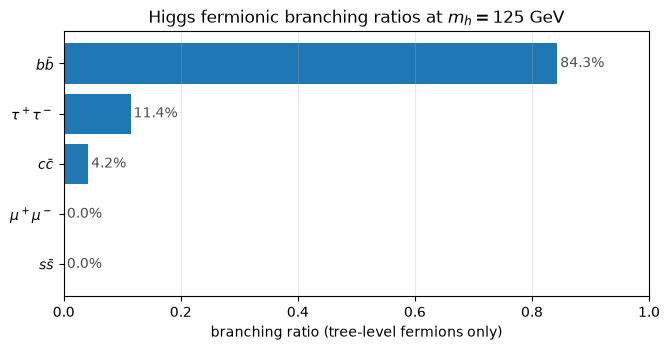

In [ ]:
labels = [str(c[1]) for c in sorted(widths_f, key=lambda k: widths_f[k])]
brs = [widths_f[c] / total_f for c in sorted(widths_f, key=lambda k: widths_f[k])]
tex = {"b": r"$b\bar b$", "tau": r"$\tau^+\tau^-$", "c": r"$c\bar c$",
       "mu": r"$\mu^+\mu^-$", "s": r"$s\bar s$"}

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.barh(range(len(labels)), brs, color="#1f77b4")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels([tex[l] for l in labels])
ax.set_xlabel("branching ratio (tree-level fermions only)")
ax.set_title(r"Higgs fermionic branching ratios at $m_h=125$ GeV")
for k, b in enumerate(brs):
    ax.text(b + 0.005, k, f"{b:.1%}", va="center", color="0.3")
ax.set_xlim(0, 1.0); ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

Now $b\bar b$ dominates — about 84% of the tree-level fermionic width — exactly as the
canonical Higgs plot shows, with $\tau\tau$ a distant second. The two facts from §7 are
both visible: the width tracks $m_f^2$ (so the heavy $b$ wins), and quarks carry the
extra $N_c=3$.

Every *tree-level fermionic* channel is now here, declared cleanly — and
`calc_f.unmatched_channels` came back empty, our guarantee that no fermion was silently
dropped. What is still missing from the plot is the **off-shell $WW^*/ZZ^*$** — which,
it turns out, is *not* beyond a tree-level engine at all. That is §11.

## 11. Off-shell decays: reopening the closed channel

Look again at where the Higgs plot said $WW$ is *closed*: below $2m_W = 160.8$ GeV the
two-body width is exactly zero, because $\sqrt{\lambda(m_h^2,m_W^2,m_W^2)}$ is imaginary
(§12.2 makes a lesson of this). Yet the measured Higgs, at 125 GeV, decays to $WW^*$
about a fifth of the time. How?

Because the Higgs does not need *two* on-shell $W$'s. It reaches **one** on-shell $W$ and
**one off-shell** $W^*$ that immediately materialises as a fermion pair:

$$h \;\to\; W\,(W^* \to f\bar f').$$

That is a **three-body** decay, $1\to3$, and it is where the machinery takes its one real
architectural step. A $1\to2$ amplitude squares a *single* vertex. Here the amplitude is
*vertex × propagator × vertex* — the $hWW$ coupling, the internal $W^*$ **propagator**

$$\frac{-i\,(g_{\mu\nu} - q_\mu q_\nu/m_W^2)}{q^2 - m_W^2 + i\,m_W\Gamma_W},$$

and the $W^*ff'$ current. The propagator's momentum $q=p_f+p_{\bar f'}$ flows *into* the
trace algebra — but $q = p_2+p_3$ is just a sum of the two fermion momenta, so the same
covariant engine from §6 contracts it with nothing new to learn.

One tidy detail: below threshold $q^2$ can never reach $m_W^2$ (its largest value is
$(m_h-m_W)^2 \approx 2000 \ll m_W^2 \approx 6500$), so the propagator never hits its
pole and the width $\Gamma_W$ in the denominator barely matters. The decay is genuinely
*off-shell*, never *resonant*.

In [ ]:
# the W and Z total widths that feed the Breit-Wigner (themselves decay outputs)
GammaW, GammaZ = 2.085, 2.4952
gZ = np.sqrt(GW**2 + G1**2)
sw2 = G1**2 / (GW**2 + G1**2)

# h -> WW*: hWW = g m_W; 9 fermion channels (3 lepton + 2 quark gen x 3 colour),
# each with the V-A coupling g/sqrt(2); factor 2 for which W is on-shell
gWW = scalar_offshell_vv_width(MH, MW, GammaW, GW * MW,
                               [(GW / np.sqrt(2), 0.0, 9)], identical=False)

# h -> ZZ*: hZZ = g_Z m_Z; real chiral Z->ff couplings; identical Z (no factor 2)
zchan = [(gZ * (T3 - Q * sw2), gZ * (-Q * sw2), Nc * cnt)
         for T3, Q, Nc, cnt in [(0.5, 0, 1, 3), (-0.5, -1, 1, 3),
                                (0.5, 2/3, 3, 2), (-0.5, -1/3, 3, 3)]]
gZZ = scalar_offshell_vv_width(MH, MZ, GammaZ, gZ * MZ, zchan, identical=True)

print(f"Gamma(h -> WW*) = {gWW*1e3:7.4f} MeV   (Keung-Marciano ~0.80)")
print(f"Gamma(h -> ZZ*) = {gZZ*1e3:7.4f} MeV   (Keung-Marciano ~0.089)")

Gamma(h -> WW*) =  0.8031 MeV   (Keung-Marciano ~0.80)
Gamma(h -> ZZ*) =  0.0888 MeV   (Keung-Marciano ~0.089)


Both land on the textbook Keung–Marciano values — the covariant $|M|^2$ integrated over
the three-body Dalitz region, cross-checked against the closed form.

It is worth *seeing* why the on-shell picture missed this. Plot the differential width
$\mathrm{d}\Gamma/\mathrm{d}q^2$ against the invariant mass $\sqrt{q^2}$ of the $W^*$ —
the mass the virtual $W$ actually carries.

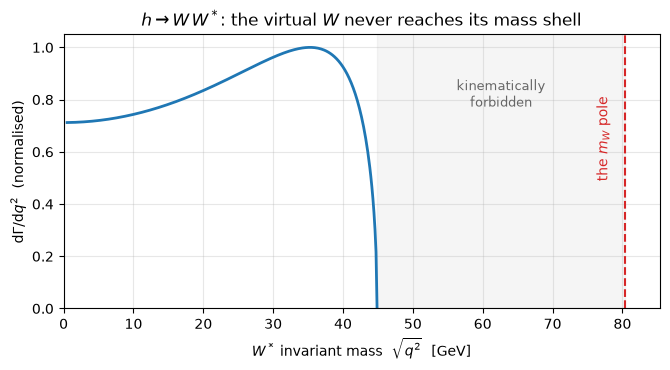

In [ ]:
mSs, mVs, s23 = sp.symbols("m_S m_V s23", positive=True)
inner = scalar_vv_s12_integral(mSs, mVs)        # the analytic inner Dalitz integral
inner_f = sp.lambdify((s23, mSs, mVs), inner, "numpy")

q = np.linspace(0.5, MH - MW, 300)              # sqrt(q^2), the W* invariant mass
with np.errstate(invalid="ignore"):
    dG = inner_f(q**2, MH, MW) / ((q**2 - MW**2)**2 + MW**2 * GammaW**2)
dG = np.nan_to_num(dG)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(q, dG / dG.max(), lw=2, color="#1f77b4")
ax.axvline(MW, ls="--", color="#d62728")
ax.text(MW - 2, 0.5, r"the $m_W$ pole", rotation=90, ha="right", color="#d62728")
ax.axvspan(MH - MW, MW, alpha=0.08, color="0.5")
ax.text((MH - MW + MW) / 2, 0.82, "kinematically\nforbidden", ha="center",
        va="center", color="0.4", fontsize=9)
ax.set_xlabel(r"$W^*$ invariant mass  $\sqrt{q^2}$  [GeV]")
ax.set_ylabel(r"$\mathrm{d}\Gamma/\mathrm{d}q^2$  (normalised)")
ax.set_title(r"$h\to W\,W^*$: the virtual $W$ never reaches its mass shell")
ax.set_xlim(0, MW + 5); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The whole distribution sits **below** the $m_W$ pole — the virtual $W$ tops out around
$m_h - m_W \approx 45$ GeV, far short of 80. An on-shell $1\to2$ calculation only ever
samples $q^2 = m_W^2$ exactly; it sees *none* of this tail, which is why it reported the
channel as flat zero. The off-shell width is the area under this curve.

Now add $WW^*$ and $ZZ^*$ to the fermion channels of §10 and read off the **complete
tree-level Higgs branching ratios**.

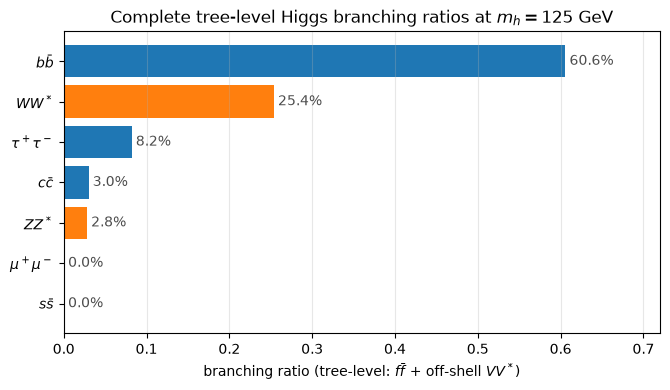

  h -> b      BR = 60.6%
  h -> WW*    BR = 25.4%
  h -> tau    BR = 8.2%
  h -> c      BR = 3.0%
  h -> ZZ*    BR = 2.8%
  h -> mu     BR = 0.0%
  h -> s      BR = 0.0%


In [ ]:
# combine: the fermion widths (widths_f, keyed by (fbar, f)) + the two off-shell ones
combined = {"WW*": gWW, "ZZ*": gZZ}
tex = {"WW*": r"$WW^*$", "ZZ*": r"$ZZ^*$", "b": r"$b\bar b$", "tau": r"$\tau^+\tau^-$",
       "c": r"$c\bar c$", "mu": r"$\mu^+\mu^-$", "s": r"$s\bar s$"}
for children, w in widths_f.items():
    combined[str(children[1])] = w
grand = sum(combined.values())

order = sorted(combined, key=lambda k: combined[k])
brs = [combined[k] / grand for k in order]

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = ["#ff7f0e" if k in ("WW*", "ZZ*") else "#1f77b4" for k in order]
ax.barh(range(len(order)), brs, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([tex[k] for k in order])
ax.set_xlabel("branching ratio (tree-level: $f\\bar f$ + off-shell $VV^*$)")
ax.set_title(r"Complete tree-level Higgs branching ratios at $m_h=125$ GeV")
for k, br in enumerate(brs):
    ax.text(br + 0.005, k, f"{br:.1%}", va="center", color="0.3")
ax.set_xlim(0, 0.72); ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

for k in sorted(combined, key=lambda k: -combined[k]):
    print(f"  h -> {k:<5}  BR = {combined[k]/grand:.1%}")

This is the **canonical Higgs picture**: $b\bar b$ dominant (~60%), $WW^*$ second
(~25%), then $\tau\tau$, $c\bar c$, $ZZ^*$. Compare with the measured Higgs — $b\bar b$
58%, $WW^*$ 21%, $gg$ 8%, $\tau\tau$ 6%, $c\bar c$ 3%, $ZZ^*$ 3% — and the only real
absentee is the loop-induced $gg$ (and $\gamma\gamma$), which a tree-level engine cannot
reach. That is **Tier 3** of `docs/manual/decays_roadmap.md`; everything else on the
plot, this notebook computed from a Lagrangian.

And notice what §12.2 is about to call a *trap* — a closed two-body channel with an
imaginary $\sqrt\lambda$ — was really a *signpost*: the channel is not gone, it has
gone **off-shell**.

*Further reading*: the closed-form $R(x)$ this section reproduces is the original
Keung & Marciano calculation (Phys. Rev. D 30, 248, 1984) in the notation of Djouadi's
review (Phys. Rept. 457, 2008, arXiv:hep-ph/0503172) — see `docs/manual/decays_roadmap.md`
§16.5 for the full citations.

## 12. Two ways to get it silently wrong

Both of these produce a plausible-looking number rather than an error. That makes them
worth more of your attention than anything else in this notebook.

### 12.1 Forgetting that a Dirac fermion is two Weyl fields

`feynlag` has no `DiracFermion`; an electron is a left-handed and a right-handed Weyl
field. So the $Z$'s left- and right-handed currents arrive as **separate vertices**, and
unless you say they are the same particle, you get two half-channels instead of one
channel — each missing the other's $g_Lg_R$ interference.

This is exactly what a `DiracParticle` bundles away — declared as one object, the two
legs *cannot* be separated. But the lower-level `particle_map` lets you make the mistake,
and it is worth seeing its size once, on the $Z'$ model we are about to build.

In [ ]:
gX = ExternalParameter("gX", 0.3, positive=True)
vx = ExternalParameter("vx", 3000.0, positive=True, unit_dim=1)
lamx = ExternalParameter("lamx", 0.1)
mux = InternalParameter("mux", unit_dim=2)

U1X = U1("U1X", coupling=gX)
S = Scalar("S", reps={U1X: 1}, component_names=["S0"])
S.expand_vev({S.components[0]: vx})
chiL = WeylFermion("chiL", reps={U1X: sp.Rational(1, 2)}, chirality="L",
                   nflavors=1, component_names=["chiL"])
chiR = WeylFermion("chiR", reps={U1X: sp.Rational(1, 2)}, chirality="R",
                   nflavors=1, component_names=["chiR"])

SdS = (dag(S) * S.mat)[0]
DS = Dmu(S)
Lx = Lagrangian()
Lx.add((dag(DS) * DS)[0], sector="kinetic")
Lx.add(-(-mux.s * SdS + lamx.s * SdS**2), sector="potential")
Lx.add(fermion_gauge_current(chiL, i) + fermion_gauge_current(chiR, i), sector="gauge")

zp_model = Model("Zprime", gauge_groups=[U1X], fields=[S, chiL, chiR, U1X.bosons("X")],
                 parameters=[gX, vx, lamx, mux], lagrangian=Lx)
zp_model.solve_tadpoles([mux])

Zp = U1X.bosons().components[0]
Sr = sp.Symbol("S0_r", real=True)
chi, chibar = sp.symbols("chi chibar")
mZp, mchi, mS = sp.symbols("m_Zp m_chi m_S", positive=True)
chi_map = {chiL.components[0][i]: chi, chiR.components[0][i]: chi,
           chiL.bar_components[0][i]: chibar, chiR.bar_components[0][i]: chibar}
print("Z' model built")

Z' model built


with particle_map (1 channel):


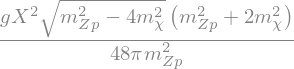

without         (2 channels):


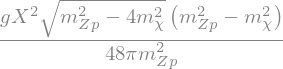

ratio wrong/right:


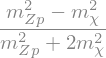

In [ ]:
# RIGHT: the two Weyl legs declared as one Dirac particle
right = DecayCalculator(zp_model, {Zp: mZp, Sr: mS, chi: mchi, chibar: mchi},
                        boson_fields=[Zp, Sr], fermion_sectors=("gauge",),
                        particle_map=chi_map)
w_right = sum(right.partial_widths(Zp).values())

# WRONG: particle_map omitted, so the L and R currents stay separate
raw_masses = {Zp: mZp, Sr: mS,
              chiL.components[0][i]: mchi, chiR.components[0][i]: mchi,
              chiL.bar_components[0][i]: mchi, chiR.bar_components[0][i]: mchi}
wrong = DecayCalculator(zp_model, raw_masses, boson_fields=[Zp, Sr],
                        fermion_sectors=("gauge",))
w_wrong = sum(wrong.partial_widths(Zp).values())

print("with particle_map (1 channel):");  display(sp.simplify(w_right))
print("without         (2 channels):");   display(sp.simplify(w_wrong))
print("ratio wrong/right:");              display(sp.simplify(w_wrong/w_right))

$$\frac{\Gamma_\text{wrong}}{\Gamma_\text{right}}
= \frac{M^2-m_\chi^2}{M^2+2m_\chi^2}\;\xrightarrow[\;m_\chi\to0\;]{}\;1.$$

Look at that limit. For light fermions the mistake is **invisible** — the two answers
agree exactly. It only appears once the daughter mass matters, because what got lost is
precisely the $g_Lg_R\,m^2/M^2$ interference term from §8. A bug that hides in the
massless limit and emerges for heavy final states is the worst kind, which is why this
notebook spends a section on it.

### 12.2 Closed channels and imaginary widths

With symbolic masses, `M >= m1 + m2` is simply undecidable, so a channel is kept. That
is the right call — you may substitute masses later that open it. But if you then plug
in numbers that leave it closed, $\lambda < 0$ and $\sqrt\lambda$ is **imaginary**. A
complex width silently poisons the total and every branching ratio.

In [ ]:
naive = calc.numeric(calc.partial_widths(h)[(Wm, Wp)], extra=numbers)
print("h -> WW at m_h = 125 GeV, substituted naively:", naive)
print("   ... imaginary, because 2 m_W = 160.8 > 125.25\n")

safe = calc.numeric_partial_widths(h, extra=numbers)
print("via numeric_partial_widths:", safe[(Wm, Wp)], " (exactly zero)")
print("branching ratios then sum to",
      sum(calc.numeric_branching_ratios(h, extra=numbers).values()))

h -> WW at m_h = 125 GeV, substituted naively: 0.7213819361810636j
   ... imaginary, because 2 m_W = 160.8 > 125.25



via numeric_partial_widths: 0.0  (exactly zero)
branching ratios then sum to 1.0


So: `partial_widths` for symbolic work, and **`numeric_partial_widths` /
`numeric_branching_ratios` whenever numbers go in** — they re-test the threshold after
substitution and return an honest zero. This is also why the Higgs-mass scan in §10
carried an explicit `np.where(grid > threshold, ...)` mask.

## 13. Your own model: a $Z'$

The point of doing this with a Lagrangian-level tool is that nothing above was specific
to the Standard Model. We already built the model in §12: a new $U(1)_X$, broken by a
singlet scalar getting a VEV, with a vector-like fermion $\chi$ charged under it. Ask it
for the width.

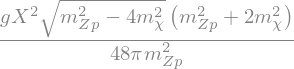

m_chi -> 0 : gX**2*m_Zp/(48*pi)    = g_X^2 m_Z' / 48 pi


In [ ]:
width_Zp = sp.simplify(sum(right.partial_widths(Zp).values()))
display(width_Zp)

# massless limit
print("m_chi -> 0 :", sp.simplify(width_Zp.subs(mchi, 0)), "   = g_X^2 m_Z' / 48 pi")

$$\Gamma(Z'\to\chi\bar\chi)
= \frac{g_X^2\,\sqrt{m_{Z'}^2-4m_\chi^2}\;\big(m_{Z'}^2+2m_\chi^2\big)}{48\pi\,m_{Z'}^2}.$$

Compare its threshold behaviour with the Higgs of §7. The fermion pair from a **vector**
comes out in an S-wave, so the width turns on as $\beta^1$, not $\beta^3$ — and there is
an extra $(1 + 2m_\chi^2/m_{Z'}^2)$ enhancement from the longitudinal polarisation.

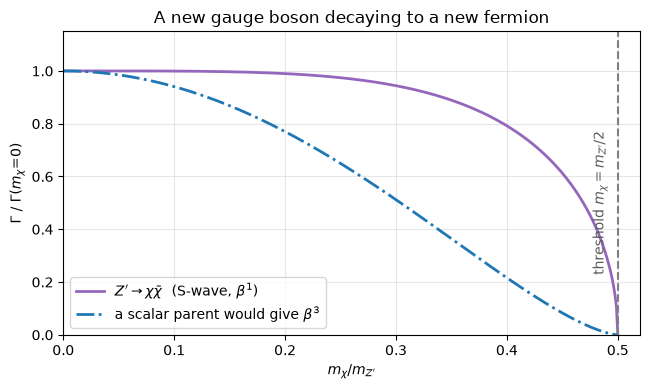

In [ ]:
f_zp = sp.lambdify(mchi, width_Zp.subs({gX.s: 0.3, mZp: 1.0}), "numpy")
r = np.linspace(0, 0.5, 400)                     # r = m_chi / m_Z'
with np.errstate(invalid='ignore'):
    y = np.where(r < 0.5, f_zp(r), 0.0)
y = np.nan_to_num(y)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(r, y/y[0], lw=2, color='#9467bd', label=r"$Z'\to\chi\bar\chi$  (S-wave, $\beta^1$)")
beta_r = np.sqrt(np.clip(1 - 4*r**2, 0, None))
ax.plot(r, beta_r**3, lw=2, ls='-.', color='#1f77b4',
        label=r'a scalar parent would give $\beta^3$')
ax.axvline(0.5, ls='--', color='0.5')
ax.text(0.492, 0.5, r'threshold $m_\chi = m_{Z^\prime}/2$', rotation=90,
        ha='right', va='center', color='0.35')
ax.set_xlabel(r"$m_\chi / m_{Z'}$")
ax.set_ylabel(r'$\Gamma$ / $\Gamma(m_\chi\!=\!0)$')
ax.set_title("A new gauge boson decaying to a new fermion")
ax.set_xlim(0, 0.52); ax.set_ylim(0, 1.15)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The vector curve stays high almost until threshold and then drops steeply, while the
scalar's $\beta^3$ bends away early. Same phase space, different dynamics — exactly the
distinction §7 promised.

## 14. Recap

You went from "what is a width?" to branching ratios for a model you invented. The
through-line:

- A width is an **inverse lifetime**; branching ratios are its shares.
- $\Gamma = \frac{1}{2M}\int\overline{|\mathcal M|^2}\,\mathrm{d}\Phi$ splits into
  **kinematics** (phase space, which closes at threshold for any theory) and
  **dynamics** (the squared amplitude).
- Spin sums turn $|\mathcal M|^2$ into a **Dirac trace** — the reason trace theorems
  are the workhorse of this subject.
- Threshold behaviour encodes **quantum numbers**: $\beta^3$ for a CP-even scalar,
  $\beta^1$ for a vector.
- The chiral structure is visible in the answer: $Z\to\nu\bar\nu$ beats
  $Z\to\tau^+\tau^-$ because the neutrino is purely left-handed.
- A **closed** two-body channel is not the end: it can go **off-shell** ($1\to3$
  through a Breit–Wigner propagator), which is how $h\to WW^*$ dominates at 125 GeV.

**API cheat-sheet**

| Call | Gives you |
|---|---|
| `kallen(x, y, z)` | the triangle function $\lambda$ |
| `TwoBodyKinematics(M, m1, m2)` | momenta, on-shell dot products, `phase_space()`, `beta` |
| `slashed(p, mu)` | $\not p$ for the trace engine |
| `dirac_trace(chain)` | the trace, still with abstract indices |
| `contract_to_dots(expr, kin.dot)` | the same, reduced to masses |
| `ffs_squared(gL, gR, kin)` | $\overline{\|\mathcal M\|^2}$ for $S\to f\bar f$ |
| `ffv_squared(gL, gR, kin)` | ... for $V\to f\bar f$ (already averaged over 3 pols) |
| `vvs_squared(c, kin)` | ... for $S\to VV$ |
| `collect_decay_vertices(...)` | every three-leg vertex, with `g_left`/`g_right` |
| `DecayCalculator(...).partial_widths(p)` | symbolic widths per channel |
| `.numeric_partial_widths(p, extra=...)` | the same as floats, **closed channels zeroed** |
| `.branching_ratios(p)` / `.numeric_branching_ratios(p, ...)` | the shares |
| `scalar_offshell_vv_width(...)` | off-shell $\Gamma(S\to V V^*\to V f\bar f')$ |

**Two rules worth remembering**

1. Pass a `particle_map` whenever a Dirac fermion appears — the error hides in the
   massless limit.
2. Use the `numeric_*` methods the moment numbers go in.

**Where to go next**

- `docs/manual/decays.md` — the algorithms chapter: how the covariant trace engine
  works, why the $\gamma_5$ term is provably droppable for 1→2, and what happens at the
  guard when it is not.
- `tests/test_pheno.py` — every width above is pinned there twice: against the closed
  form, and against an independent explicit-$4\times4$-matrix evaluation.
- `examples/sm_decays.py` — the same Standard Model as a plain script.
- Implemented: **1→2** (SSS, FFS, FFV, VVS) and **1→3 off-shell** $VV^*$. The
  loop-induced $gg$/$\gamma\gamma$ (Tier 3 of `docs/manual/decays_roadmap.md`) and the
  FFFF / $t\to bW^*$ three-body topologies are the remaining frontier.